In [1]:
# -*- coding: utf-8 -*-
import logging
from pathlib import Path
import os
import pandas as pd
import numpy as np

project_dir =  Path(globals()['_dh'][0]).parent

Let's add the other external data, consisting of external data from SDSS_DR7, we will add DH, DO, DC and DZ espectrums. Let's start by creating a folder for our files.

In [2]:
current_dir =  Path(globals()['_dh'][0])
try:
    os.mkdir(os.path.join(current_dir, '2.0-jrb-external-data-exploration'))
except:
    print("Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.")

Failed to create folder. Perhaps the folder already exists, or there's a permissions issue.


Let's first explor some of the files and figure out what is their wavelenght axis.

In [3]:
import numpy as np
# Set up matplotlib
import matplotlib.pyplot as plt


from astropy.io import fits
from astropy.convolution import convolve, Box1DKernel

def extraction(fitfile):
    hdu  = fits.open(fitfile)
    data = hdu['COADD'].data
    w = 10**data['loglam']
    f = data['flux']*1e-17
    return w,f

def convolution(w,f, box=5):
    kernel = Box1DKernel(box)
    smoothed = convolve(f, kernel)
    return w,smoothed

[3809.7805 3810.659  3811.5356 ... 9181.21   9183.327  9185.439 ] 3823


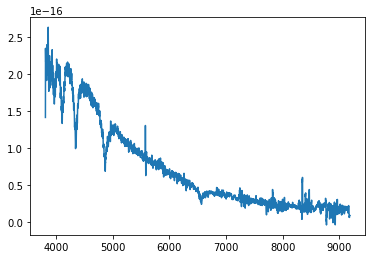

In [4]:
fits_path = os.path.join(project_dir, r'data\external\SDSS_DR7\DAH\spec-00287-52023-0253.fits')

w,f = extraction(fits_path)
w, smoothed = convolution(w, f)

plt.plot(w, smoothed)

print(w, len(w))

[3806.2727 3807.1504 3808.0261 ... 9206.613  9208.736  9210.8545] 3839


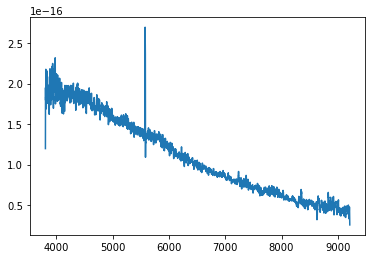

In [5]:
fits_path = os.path.join(project_dir, r'data\external\SDSS_DR7\DC\spec-00309-51994-0085.fits')

w,f = extraction(fits_path)
w, smoothed = convolution(w, f)

plt.plot(w, smoothed)

print(w, len(w))

In [6]:
dat_path = os.path.join(project_dir, r'data\raw\sdss_dat_files\cb_uvex3\SDSSJ074107.26+310612.8_15016-59146-0062_4551581537.dat')
sed = np.loadtxt(dat_path, unpack = True)
wavelength = sed[0,:]
flux = sed[1,:]
print(wavelength, len(wavelength))

[ 3565.956  3566.777  3567.599 ... 10391.558 10393.954 10396.352] 4648


In [7]:
wavelength = sed[0,48:-400]
flux = sed[1,48:-400]
print(wavelength, len(wavelength))

[3605.589 3606.418 3607.25  ... 9477.212 9479.393 9481.578] 4200


It seems like we clearly need to interpolate this data to the common wavelenght from the dat files, but can we? Perhaps we will need to recreate our hole data set, but trimming the edges a little more. Lets settle on how much

In [8]:
wavelength = sed[0,298:-600]
flux = sed[1,48:-400]
print(wavelength, len(wavelength))

[3819.238 3820.119 3820.998 ... 9050.666 9052.749 9054.836] 3750


This seems about enough. Let's use our source code to remake the numpy matrices.

In [28]:
import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../src'))
import src.features.build_features as bfs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
bfs.basic_spectrum_pipeline(prefix='lpv1', csv_relative_path=r'data\processed\lpv1_match_labels.csv', first_bin=298, last_bin=-600, relative_save_folder='notebooks\\2.0-jrb-external-data-exploration')

## External Data set

Now let's re build our external dataset with our new windows and wavelenght interpolation axis. First, we must fetch some data.

In [11]:
import src.visualization.visualize as vsz

train_label_matrix = np.load(os.path.join(project_dir, r'notebooks\\2.0-jrb-external-data-exploration\\lpv1_train_label_matrix.npy'))

train_csv_path = os.path.join(project_dir, r'notebooks\2.0-jrb-external-data-exploration\train_set.csv')
train_set = pd.read_csv (train_csv_path)
ohe_dict = vsz.ohe_decoder(train_set['classID'], train_label_matrix)
star_class = vsz.sort_ohe(ohe_dict)

In [12]:
ohe_dict

{'WDA': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDZ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 'WDB': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 'WDO': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 'WD+MS': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WD': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'sdX': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 'WDH': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 'WDELM': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'WDC': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 'CV': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'WDQ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])}

In [13]:
# Loading crossmatch information

crossmatch_path = os.path.join(project_dir, r'data\external\crossmatch')
cm_info = pd.DataFrame()

for filename in os.listdir(crossmatch_path):
    if not (filename.endswith('ipynb') or filename.endswith('da')):
        csv_path = os.path.join(crossmatch_path, filename)
        star_set = pd.read_csv(csv_path, usecols=['PLATEID','MJDID','FIBERID','THING_ID', 'source_id'])
        star_set['classID'] = filename.split('_')[-1]
        cm_info = cm_info.append(star_set)
cm_info.reset_index(drop=True, inplace=True)
cm_info = cm_info.astype({"PLATEID": 'int64', "MJDID": 'int64', "FIBERID" : 'int64', "THING_ID" : 'int64'})

In [14]:
cm_info

,PLATEID,MJDID,FIBERID,THING_ID,source_id,classID
0,6290,56238,770,329176691,1876751655807530752,cv
1,8227,57427,629,493785950,1571768231438756864,cv
2,7117,56685,854,524628776,1566956008344163456,cv
3,4999,55721,420,390531345,1333882980892489472,cv
4,4200,55499,122,83907657,2678566696432062336,cv
...,...,...,...,...,...,...
1700,6402,56334,614,357580047,4019646766906456448,dz
1701,5888,56041,474,270361011,3983562478910025728,dz
1702,4355,55533,770,63723465,2449345460075810048,dz
1703,4638,55956,540,449441017,814515018401000064,dz


In [15]:
ext_train_set, ext_test_set, ext_valid_set = bfs.make_stratified_sets(cm_info, train_set_size=0.6, validation_test_split=0.5)

In [16]:
ext_data_dict = { 'cv' : 'CV',  'da' : 'WDA', 'da+ms' : 'WD+MS', 'db+ms' : 'WD+MS', 'db' : 'WDB', 'dq' : 'WDQ', 'dz' : 'WDZ', 'wd' : 'WD'}

In [17]:
# Define base wavelenght

dat_path = os.path.join(project_dir, r'data\raw\sdss_dat_files\cb_uvex3\SDSSJ133448.14+374547.9_15299-59369-0406_4602877123.dat')
sed = np.loadtxt(dat_path, unpack = True)
base_wavelenght = sed[0,298:-600]

In [18]:
# Call external pre processing function

ext_data_path = os.path.join(project_dir, r'data\external\fits_spectrums')
ext_train_spectrum_matrix, ext_train_label_matrix = bfs.ext_data_processing_and_loading(ext_data_path, ext_train_set, base_wavelenght, ohe_dict, ext_data_dict, first_bin=298, last_bin=-600)
ext_valid_spectrum_matrix, ext_valid_label_matrix = bfs.ext_data_processing_and_loading(ext_data_path, ext_valid_set, base_wavelenght, ohe_dict, ext_data_dict, first_bin=298, last_bin=-600)
ext_test_spectrum_matrix, ext_test_label_matrix = bfs.ext_data_processing_and_loading(ext_data_path, ext_test_set, base_wavelenght, ohe_dict, ext_data_dict, first_bin=298, last_bin=-600)

In [24]:
print(ext_train_spectrum_matrix.shape, ext_train_label_matrix.shape, ext_valid_spectrum_matrix.shape,  ext_valid_label_matrix.shape, ext_test_spectrum_matrix.shape, ext_test_label_matrix.shape)

(1022, 3750) (1022, 12) (341, 3750) (341, 12) (341, 3750) (341, 12)


## SDSS Data Set

Now that we have our original data set preprocessed again, we can begin to process the sdss dataset in a similar manner. First, we will make our dataframe.

In [19]:
dr7_info = pd.DataFrame(columns=['filename', 'classID'])

sdss_dr7_path = os.path.join(project_dir, 'data\external\SDSS_DR7')
for root, dirs, files in os.walk(sdss_dr7_path):
    for folder in dirs:
        folder_path = os.path.join(sdss_dr7_path, folder)
        for filename in os.listdir(folder_path):
            df2 = {'filename': os.path.join(folder_path, filename) , 'classID': folder}
            dr7_info = dr7_info.append(df2, ignore_index=True)


In [20]:
pd.set_option("display.max_colwidth", -1)
dr7_info

C:\Users\mafalsa\AppData\Local\Temp/ipykernel_13684/888064578.py:1: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option("display.max_colwidth", -1)


,filename,classID
0,c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\external\SDSS_DR7\DAH\spec-00287-52023-0253.fits,DAH
1,c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\external\SDSS_DR7\DAH\spec-00288-52000-0276.fits,DAH
2,c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\external\SDSS_DR7\DAH\spec-00289-51990-0349.fits,DAH
3,c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\external\SDSS_DR7\DAH\spec-00290-51941-0166.fits,DAH
4,c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\external\SDSS_DR7\DAH\spec-00307-51663-0595.fits,DAH
...,...,...
1491,c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\external\SDSS_DR7\DZ\spec-02922-54612-0509.fits,DZ
1492,c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\external\SDSS_DR7\DZ\spec-02931-54590-0302.fits,DZ
1493,c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\external\SDSS_DR7\DZ\spec-02936-54626-0537.fits,DZ
1494,c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\data\external\SDSS_DR7\DZ\spec-02944-54523-0586.fits,DZ


We can now make stratified sets, build our features and then add everything up!

In [25]:
dr7_train_set, dr7_test_set, dr7_valid_set = bfs.make_stratified_sets(dr7_info, train_set_size=0.6, validation_test_split=0.5)

Next, we will fetch the variables we need to process the dataset using a similar function from the 1.0 notebook version.

In [44]:
train_label_matrix = np.load(os.path.join(project_dir, r'notebooks\\2.0-jrb-external-data-exploration\\lpv1_train_label_matrix.npy'))
valid_label_matrix = np.load(os.path.join(project_dir, r'notebooks\\2.0-jrb-external-data-exploration\\lpv1_valid_label_matrix.npy'))
test_label_matrix = np.load(os.path.join(project_dir, r'notebooks\\2.0-jrb-external-data-exploration\\lpv1_test_label_matrix.npy'))
train_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\\2.0-jrb-external-data-exploration\\lpv1_train_spectrum_matrix.npy'))
valid_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\\2.0-jrb-external-data-exploration\\lpv1_valid_spectrum_matrix.npy'))
test_spectrum_matrix = np.load(os.path.join(project_dir, r'notebooks\\2.0-jrb-external-data-exploration\\lpv1_test_spectrum_matrix.npy'))

In [22]:
ext_data_dict = { 'DAH' : 'WDH',  'DBH' : 'WDH', 'DC' : 'WDC', 'DO' : 'WDO', 'DZ' : 'WDZ'}

In [33]:
import importlib
import src.features.build_features as bfs
importlib.reload(bfs)

<module 'src.features.build_features' from 'c:\\Users\\mafalsa\\OneDrive - Universidad Técnica Federico Santa María\\Documentos\\GitHub\\ML_NPF\\src\\features\\build_features.py'>

In [36]:
# Call external pre processing function

ext_data_path = os.path.join(project_dir, r'data\external\SDSS_DR7')
dr7_train_spectrum_matrix, dr7_train_label_matrix = bfs.ext_data_processing_and_loading(ext_data_path, dr7_train_set, base_wavelenght, ohe_dict, ext_data_dict, first_bin=298, last_bin=-600, full_filename=True)
dr7_valid_spectrum_matrix, dr7_valid_label_matrix = bfs.ext_data_processing_and_loading(ext_data_path, dr7_valid_set, base_wavelenght, ohe_dict, ext_data_dict, first_bin=298, last_bin=-600, full_filename=True)
dr7_test_spectrum_matrix, dr7_test_label_matrix = bfs.ext_data_processing_and_loading(ext_data_path, dr7_test_set, base_wavelenght, ohe_dict, ext_data_dict, first_bin=298, last_bin=-600, full_filename=True)

In [37]:
print(dr7_train_spectrum_matrix.shape, dr7_train_label_matrix.shape, dr7_valid_spectrum_matrix.shape,  dr7_valid_label_matrix.shape, dr7_test_spectrum_matrix.shape, dr7_test_label_matrix.shape)

(897, 3750) (897, 12) (300, 3750) (300, 12) (299, 3750) (299, 12)


## Concatenating and model training.

In [45]:
# Concatenate numpy arrays of train and test matrices

#train
train_label_matrix = np.concatenate((train_label_matrix, ext_train_label_matrix, dr7_train_label_matrix))
train_spectrum_matrix = np.concatenate((train_spectrum_matrix, ext_train_spectrum_matrix, dr7_train_spectrum_matrix))

#valid
valid_label_matrix = np.concatenate((valid_label_matrix, ext_valid_label_matrix, dr7_valid_label_matrix))
valid_spectrum_matrix = np.concatenate((valid_spectrum_matrix, ext_valid_spectrum_matrix, dr7_valid_spectrum_matrix))

#test
test_label_matrix = np.concatenate((test_label_matrix, ext_test_label_matrix, dr7_test_label_matrix))
test_spectrum_matrix = np.concatenate((test_spectrum_matrix, ext_test_spectrum_matrix, dr7_test_spectrum_matrix))

In [46]:
print(train_spectrum_matrix.shape, train_label_matrix.shape, valid_spectrum_matrix.shape,  valid_label_matrix.shape, test_spectrum_matrix.shape, test_label_matrix.shape)

(5285, 3750) (5285, 12) (1764, 3750) (1764, 12) (1764, 3750) (1764, 12)


In [47]:
# you can run pip install imblearn to get the imbalanced learn module.
# Resampling the majority dataset in order to balance the set.

from imblearn.over_sampling import RandomOverSampler
over_sampler = RandomOverSampler(random_state=40, sampling_strategy='not majority')
X_over, Y_over = over_sampler.fit_resample(train_spectrum_matrix, train_label_matrix)

In [48]:
_, counts = np.unique(Y_over, axis=0, return_counts=True)
counts

array([2169, 2169, 2169, 2169, 2169, 2169, 2169, 2169, 2169, 2169, 2169,
       2169], dtype=int64)

In [49]:
# Save numpy matrices

np.save(os.path.join(current_dir,'2.0-jrb-external-data-exploration\\training_spectrum_matrix.npy'), train_spectrum_matrix)
np.save(os.path.join(current_dir,'2.0-jrb-external-data-exploration\\training_label_matrix.npy'), train_label_matrix)
np.save(os.path.join(current_dir,'2.0-jrb-external-data-exploration\\valid_spectrum_matrix.npy'), valid_spectrum_matrix)
np.save(os.path.join(current_dir,'2.0-jrb-external-data-exploration\\valid_label_matrix.npy'), valid_label_matrix)
np.save(os.path.join(current_dir,'2.0-jrb-external-data-exploration\\test_spectrum_matrix.npy'), test_spectrum_matrix)
np.save(os.path.join(current_dir,'2.0-jrb-external-data-exploration\\test_label_matrix.npy'), test_label_matrix)

## Neural Nertwork Training

In [50]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
from keras.layers import Conv1D
from keras.layers import MaxPooling1D
from keras.layers import Flatten
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from keras.layers.core import Dropout

In [51]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=15)
mc = ModelCheckpoint( os.path.join(current_dir,'2.0-jrb-external-data-exploration\\best_model_try2.h5'), monitor='val_loss', mode='min', verbose=1, save_best_only=True)

model = Sequential([Conv1D(filters=128, kernel_size=4, activation='relu', strides=2, input_shape=(X_over.shape[1],1)),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=64, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=32, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Conv1D(filters=16, kernel_size=4, activation='relu', strides=2),
                    MaxPooling1D(pool_size=2),
                    Flatten(),
                    Dense(128, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.5),
                    Dense(64, activation='relu', kernel_initializer='uniform'),
                    Dropout(0.5),
                    Dense(32, activation='relu', kernel_initializer='uniform'),
                    Dense(len(star_class), activation='softmax', kernel_initializer='uniform')])

opt = keras.optimizers.Adam(learning_rate=0.0004)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
history = model.fit(X_over, Y_over, batch_size=256, epochs=60 , validation_data=(valid_spectrum_matrix, valid_label_matrix), callbacks=[es, mc])

Epoch 1/60
102/102 [==============================] - ETA: 0s - loss: 2.3813 - accuracy: 0.1345
Epoch 1: val_loss improved from inf to 2.23890, saving model to c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\notebooks\1.0-jrb-external-data-exploration\best_model_try2.h5
102/102 [==============================] - 102s 990ms/step - loss: 2.3813 - accuracy: 0.1345 - val_loss: 2.2389 - val_accuracy: 0.1570
Epoch 2/60
102/102 [==============================] - ETA: 0s - loss: 2.0742 - accuracy: 0.2610
Epoch 2: val_loss improved from 2.23890 to 1.88922, saving model to c:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\notebooks\1.0-jrb-external-data-exploration\best_model_try2.h5
102/102 [==============================] - 99s 971ms/step - loss: 2.0742 - accuracy: 0.2610 - val_loss: 1.8892 - val_accuracy: 0.3827
Epoch 3/60
102/102 [==============================] - ETA: 0s - loss: 1.7974 - accuracy: 0.37

In [52]:
from sklearn.metrics import confusion_matrix

best_model = r'C:\Users\mafalsa\OneDrive - Universidad Técnica Federico Santa María\Documentos\GitHub\ML_NPF\notebooks\1.0-jrb-external-data-exploration\best_model_try2.h5'
model = keras.models.load_model(best_model)
valid_sample_output = model.predict(test_spectrum_matrix, batch_size=20)
predict_class = np.argmax(valid_sample_output, axis=1)
actual_class = np.argmax(test_label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class, normalize='true')

89/89 [==============================] - 2s 19ms/step


In [53]:
test_label_matrix.shape, test_spectrum_matrix.shape

((1764, 12), (1764, 3750))

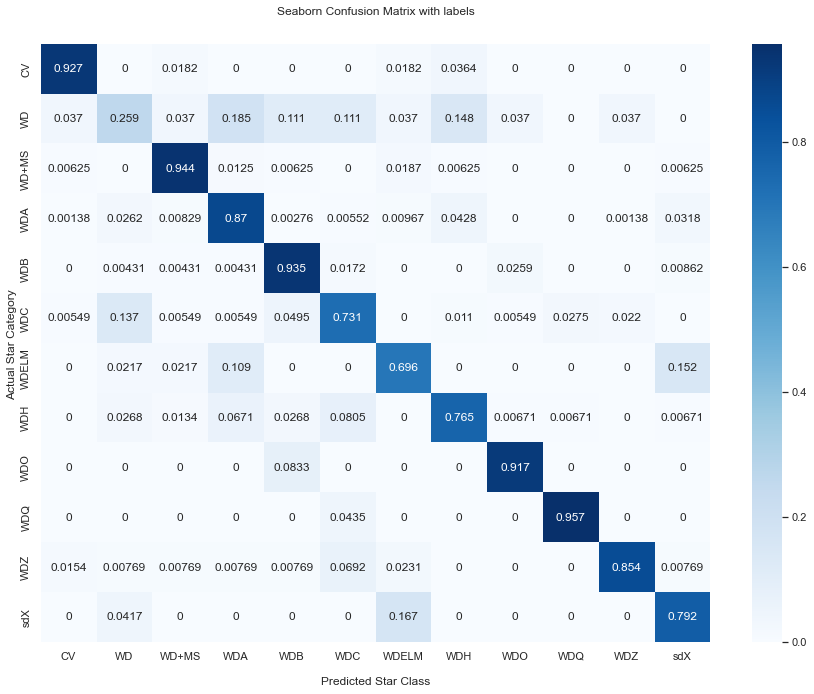

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(rc = {'figure.figsize':(15,11)})
ax = sns.heatmap(cf_matrix, annot=True, fmt='.3g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Star Class')
ax.set_ylabel('Actual Star Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()

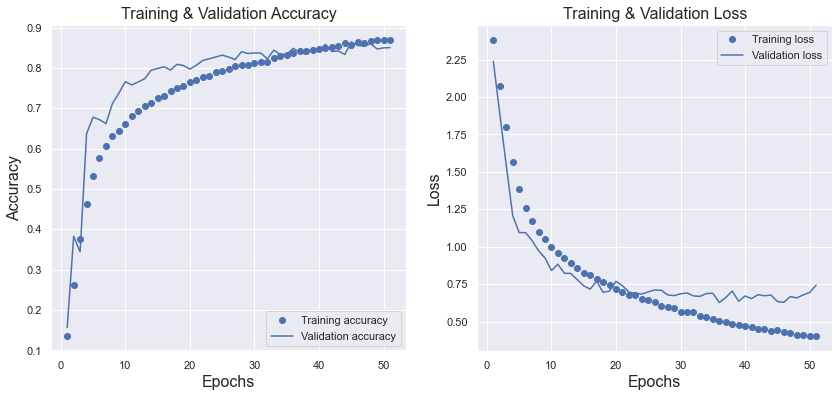

In [55]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
 
epochs = range(1, len(loss_values) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
#
# Plot the model accuracy vs Epochs
#
ax[0].plot(epochs, accuracy, 'bo', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'b', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()
#
# Plot the loss vs Epochs
#
ax[1].plot(epochs, loss_values, 'bo', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'b', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()